In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns  

from math import comb, factorial
import itertools
import fractions
from fractions import Fraction

from scipy import stats, special
import statsmodels.api as sm
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import matplotlib.pyplot as plt

The Scenario 
 
You are a data  analyst  working for a multinational company with  4,600 employees with multiple 
departments, including Sales, Marketing, Finance, and Human Resources. The company is 
interested in understanding the factors that influence employee concerns, such as (but not limited 
to)  compensation,  motivation  and  career  progression.  The  leadership  team  has  asked  you  to 
conduct a statistical analysis to uncover any potential insights. 

In [8]:
# Step 1a: Load the data and identify the types of data present
employee_data = pd.read_csv('Employee_Data.csv')
employee_data.head(10)

,Name,Salary,DOJ,Age,Gender,Dependents,HA,COLA,CPF,Gross Salary,Insurance,Marital Status,In Company Years,Year of Experience,Department,Position
0,ZuLzMAsP,88438.99,10/25/2019,36,Female,2,7142.101,20872.462360,13117.374283,103336.179077,Medical,Married,4,15,Marketing,Regional Marketing Manager
1,xQYGOrHv,137819.29,11/8/2020,57,Female,4,4660.071,32526.693747,20441.518050,154564.536697,Medical,Married,3,36,Marketing,National Marketing Manager
2,jehfxCGw,81316.12,1/20/2014,37,Male,3,5485.388,19191.395718,12060.901886,93932.001832,NaN,Divorced,10,16,Marketing,Senior Marketing Executive
3,yCezYiFJ,111420.62,2/13/2012,55,Female,1,7822.938,26296.350706,16526.036485,129013.872221,Life,Divorced,12,34,Sales,National Sales Manager
4,WDQboEZv,16185.35,5/4/2020,24,Other,2,8137.465,3819.900122,2400.630015,25742.085107,Medical,Married,4,3,Finance,Accounts Intern
5,lMuWiuUV,43619.96,8/24/2022,22,Male,0,8169.004,10294.735085,6469.763410,55613.935675,Both,Single,1,1,IT,Software Engineer I
6,NIQYRMyr,58861.85,11/18/2016,31,Other,3,4547.815,13891.969465,8730.458336,68571.176129,Medical,Divorced,7,10,Finance,Account Associate
7,UExTWkoi,131466.91,5/21/2008,55,Other,2,6923.309,31027.470243,19499.325629,149918.363614,NaN,Divorced,16,34,Finance,National Account Head
8,QBqywSmi,136432.19,6/23/2006,50,Male,1,5819.781,32199.324647,20235.781758,154215.513890,Medical,Widowed,18,29,Finance,National Account Head
9,qudAWoOL,90507.35,6/15/2014,34,Other,1,6041.265,21360.615450,13424.155854,104485.074596,Both,Married,10,13,IT,QA Lead


In [10]:
# Step 1b: Load the data and identify the types of data present (nulls?)
employee_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4600 entries, 0 to 4599
Data columns (total 16 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Name                4600 non-null   object 
 1   Salary              4600 non-null   float64
 2   DOJ                 4600 non-null   object 
 3   Age                 4600 non-null   int64  
 4   Gender              4600 non-null   object 
 5   Dependents          4600 non-null   int64  
 6   HA                  4600 non-null   float64
 7   COLA                4600 non-null   float64
 8   CPF                 4600 non-null   float64
 9   Gross Salary        4600 non-null   float64
 10  Insurance           3464 non-null   object 
 11  Marital Status      4600 non-null   object 
 12  In Company Years    4600 non-null   int64  
 13  Year of Experience  4600 non-null   int64  
 14  Department          4600 non-null   object 
 15  Position            4600 non-null   object 
dtypes: flo

## DESCRIPTIVE STATISTICS

In [13]:
# Step 2a: For all the numerical variables, we have the descriptive stats in the table
employee_data.describe().T

,count,mean,std,min,25%,50%,75%,max
Salary,4600.0,94292.524720,33983.208928,15042.700000,70548.410000,96732.995000,122100.132500,149991.340000
Age,4600.0,40.386739,11.360860,21.000000,30.000000,40.000000,50.250000,60.000000
Dependents,4600.0,1.960000,1.298521,0.000000,1.000000,2.000000,3.000000,4.000000
HA,4600.0,7999.620354,2330.275836,3127.273000,6260.064750,7736.742000,9548.199500,14787.699000
COLA,4600.0,22253.953523,8020.368044,3550.223601,16650.111363,22829.928260,28816.819592,35399.416010
CPF,4600.0,13985.577389,5040.429237,2231.150832,10463.822564,14347.550791,18110.034251,22246.890721
Gross Salary,4600.0,110560.521207,37523.647811,22624.827875,85172.758463,111097.478064,141967.946456,173050.731289
In Company Years,4600.0,9.936522,8.818178,0.000000,3.000000,7.000000,15.000000,39.000000
Year of Experience,4600.0,19.386739,11.360860,0.000000,9.000000,19.000000,29.250000,39.000000


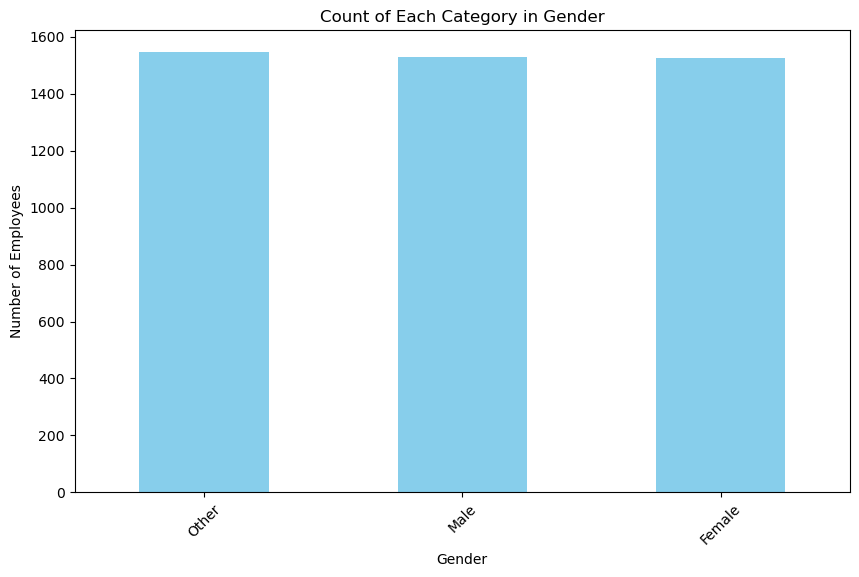

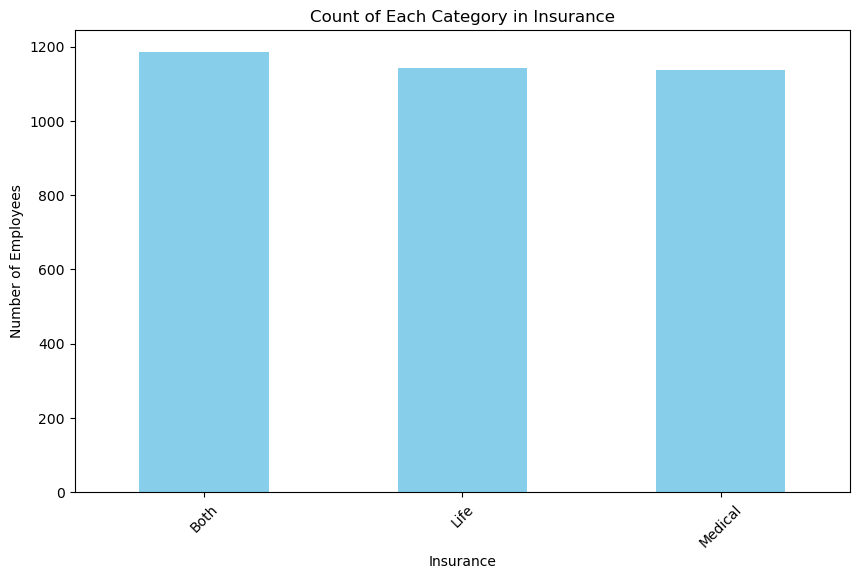

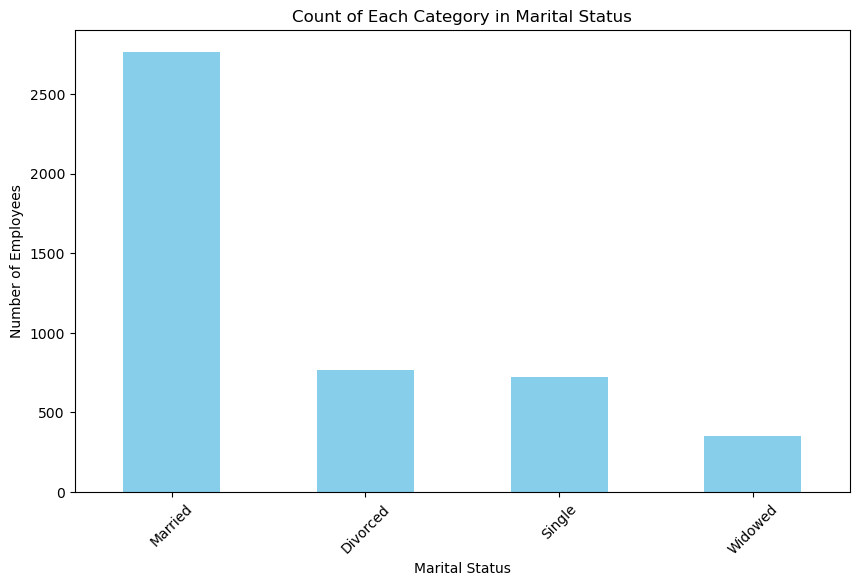

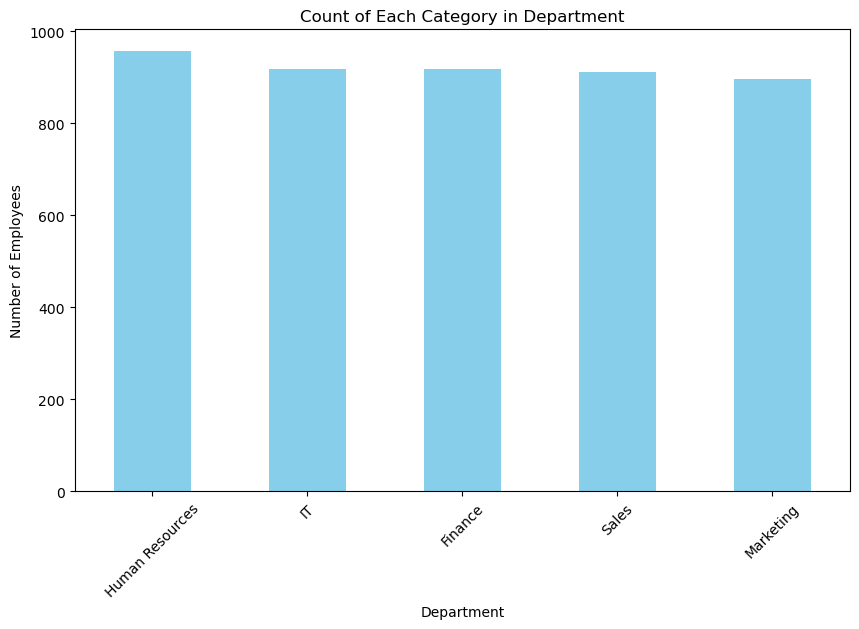

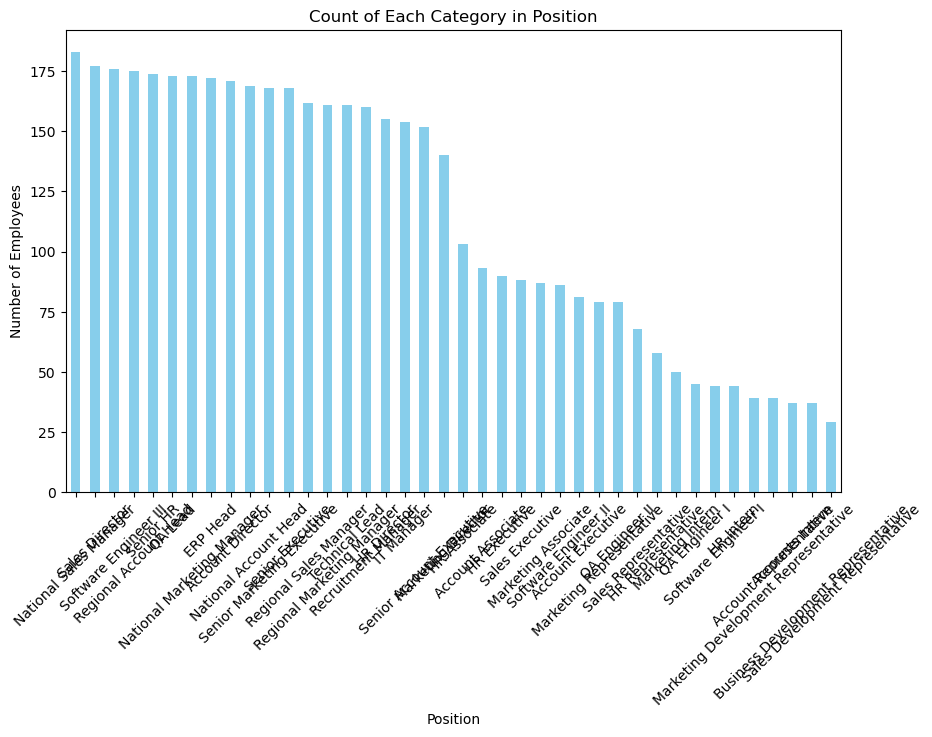

In [15]:
# Step 2b: For all the categorical variables, we have the descriptive stats in the plot

# List of categorical columns you want to plot
categorical_columns = ['Gender','Insurance','Marital Status', 'Department', 'Position', ]

for column in categorical_columns:
    category_counts = employee_data[column].value_counts()
    
    # Plotting the results
    plt.figure(figsize=(10, 6))
    category_counts.plot(kind='bar', color='skyblue')
    plt.title(f'Count of Each Category in {column}')
    plt.xlabel(column)
    plt.ylabel('Number of Employees')
    plt.xticks(rotation=45)
    plt.show()

In [17]:
# Step 3: Drop all the irrelavant columns to the problem
# Either way Insurance has missing information and we don't require it for our analysis
employee_data = employee_data.drop(['Name','DOJ','Dependents','Insurance','Marital Status'], axis=1)

In [19]:
# Step 4: Trying to get as much information about the problem
# Step 4a: Find the unique positions present in the company
unique_positions = employee_data['Position'].unique()
print("The unique positions present in the company: \n", unique_positions)
print("The number of unique positions present in the company: \n", len(unique_positions))

The unique positions present in the company: 
 ['Regional Marketing Manager' 'National Marketing Manager'
 'Senior Marketing Executive' 'National Sales Manager' 'Accounts Intern'
 'Software Engineer I' 'Account Associate' 'National Account Head'
 'QA Lead' 'Account Director' 'HR Director' 'Sales Director'
 'Technical Lead' 'ERP Head' 'HR Executive' 'Marketing Intern'
 'Regional Sales Manager' 'Marketing Development Representative'
 'Software Engineer II' 'HR Representative' 'HR Associate'
 'Recruitment Manager' 'Senior Executive' 'Regional Account Head'
 'Marketing Representative' 'Software Engineer III' 'Senior HR'
 'Marketing Director' 'IT Manager' 'QA Engineer II' 'Account Executive'
 'Senior Account Executive' 'QA Engineer I'
 'Business Development Representative' 'Sales Executive' 'HR Intern'
 'Marketing Associate' 'Sales Development Representative'
 'Sales Representative' 'Account Representative']
The number of unique positions present in the company: 
 40


In [21]:
# Step 4b: Trying of collate the different keywords in the positions to identify a hierarchy
position_keywords = ['Manager','Executive','Representative','Intern','Engineer','Associate','Head','Lead','Senior','Director']

# Let's find and replace the positions with the keyword positions
employee_data['Position'] = employee_data['Position'].apply(lambda x: next((keyword for keyword in position_keywords if keyword in x), 'Other'))

employee_data.head(10)

,Salary,Age,Gender,HA,COLA,CPF,Gross Salary,In Company Years,Year of Experience,Department,Position
0,88438.99,36,Female,7142.101,20872.462360,13117.374283,103336.179077,4,15,Marketing,Manager
1,137819.29,57,Female,4660.071,32526.693747,20441.518050,154564.536697,3,36,Marketing,Manager
2,81316.12,37,Male,5485.388,19191.395718,12060.901886,93932.001832,10,16,Marketing,Executive
3,111420.62,55,Female,7822.938,26296.350706,16526.036485,129013.872221,12,34,Sales,Manager
4,16185.35,24,Other,8137.465,3819.900122,2400.630015,25742.085107,4,3,Finance,Intern
5,43619.96,22,Male,8169.004,10294.735085,6469.763410,55613.935675,1,1,IT,Engineer
6,58861.85,31,Other,4547.815,13891.969465,8730.458336,68571.176129,7,10,Finance,Associate
7,131466.91,55,Other,6923.309,31027.470243,19499.325629,149918.363614,16,34,Finance,Head
8,136432.19,50,Male,5819.781,32199.324647,20235.781758,154215.513890,18,29,Finance,Head
9,90507.35,34,Other,6041.265,21360.615450,13424.155854,104485.074596,10,13,IT,Lead


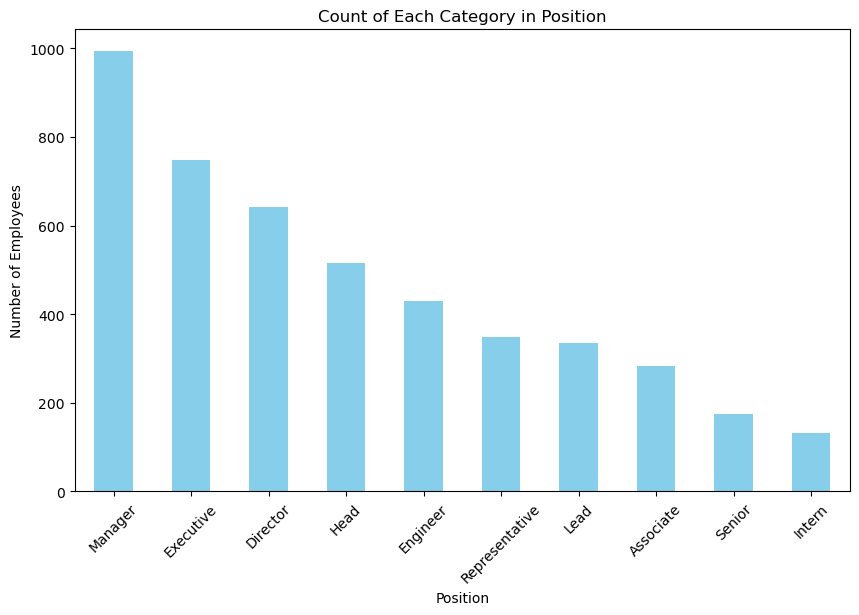

In [23]:
# Step 4c: Trying to find number of employees per position
position_counts = employee_data["Position"].value_counts()

# Plotting the results
plt.figure(figsize=(10, 6))
position_counts.plot(kind='bar', color='skyblue')
plt.title(f'Count of Each Category in Position')
plt.xlabel('Position')
plt.ylabel('Number of Employees')
plt.xticks(rotation=45)
plt.show()

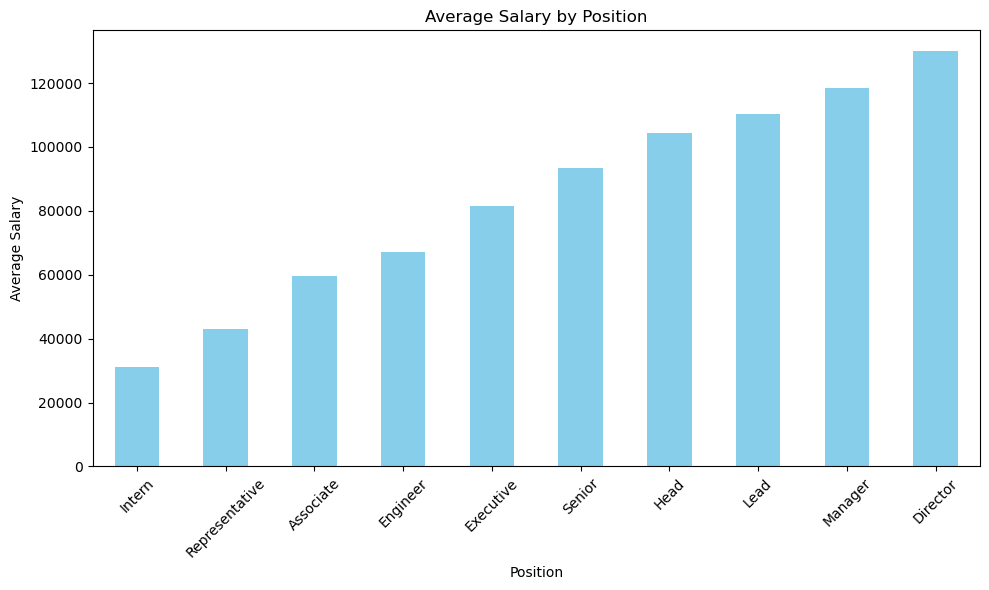

In [25]:
# Step 4d(i): Trying to find the average salary in each position to get an idea of hierarchy

average_salaries = employee_data.groupby('Position')['Salary'].mean().sort_values()

# Plot the average salaries for each position
plt.figure(figsize=(10, 6))
average_salaries.plot(kind='bar', color='skyblue')
plt.title('Average Salary by Position')
plt.xlabel('Position')
plt.ylabel('Average Salary')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

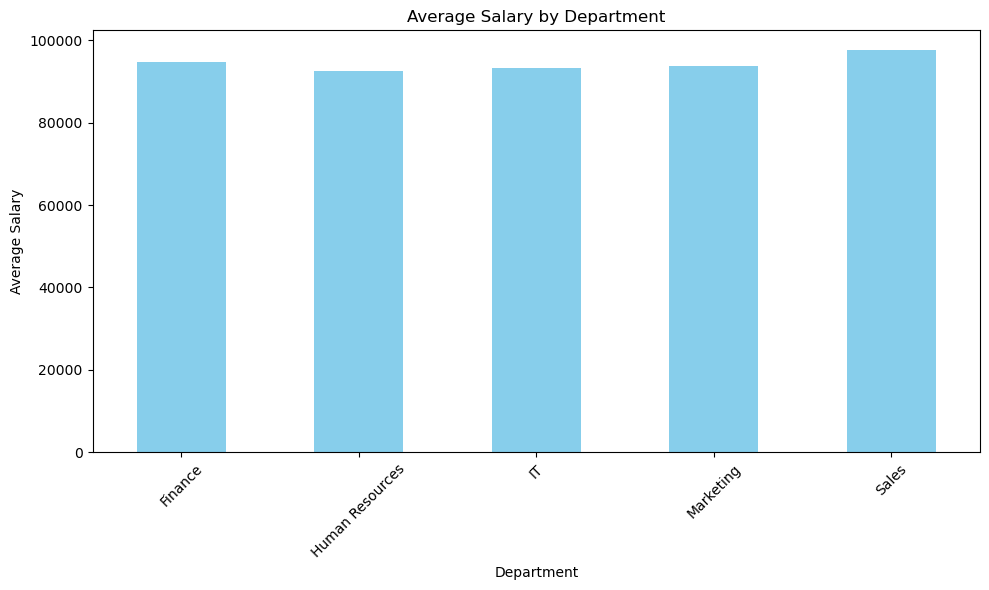

In [27]:
# Step4d(ii) Bar plot for Average Salary by Department
plt.figure(figsize=(10, 6))
employee_data.groupby('Department')['Salary'].mean().plot(kind='bar', color='skyblue')
plt.title('Average Salary by Department')
plt.xlabel('Department')
plt.ylabel('Average Salary')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

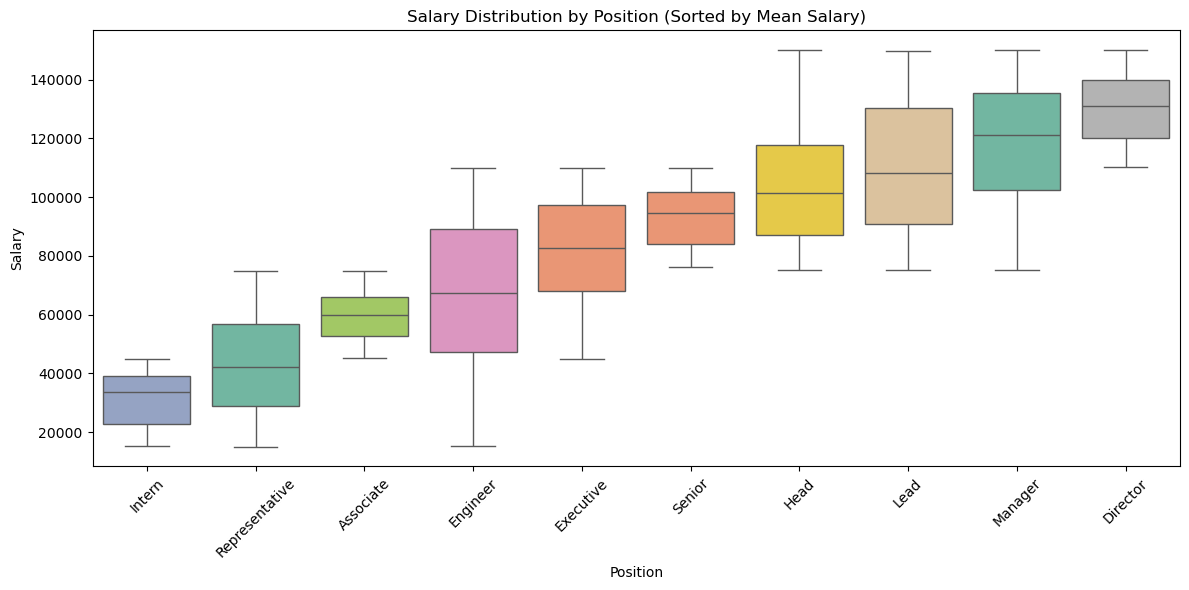

In [29]:
# Step 4e: Trying to find the average salary in each position to get an idea of hierarchy

# Calculate the mean salary for each position and sort by ascending order
average_salaries = average_salaries.index

plt.figure(figsize=(12, 6))
sns.boxplot(x='Position', y='Salary', data=employee_data, order=average_salaries, hue='Position', palette='Set2', dodge=False, legend=False)
plt.title('Salary Distribution by Position (Sorted by Mean Salary)')
plt.xlabel('Position')
plt.ylabel('Salary')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

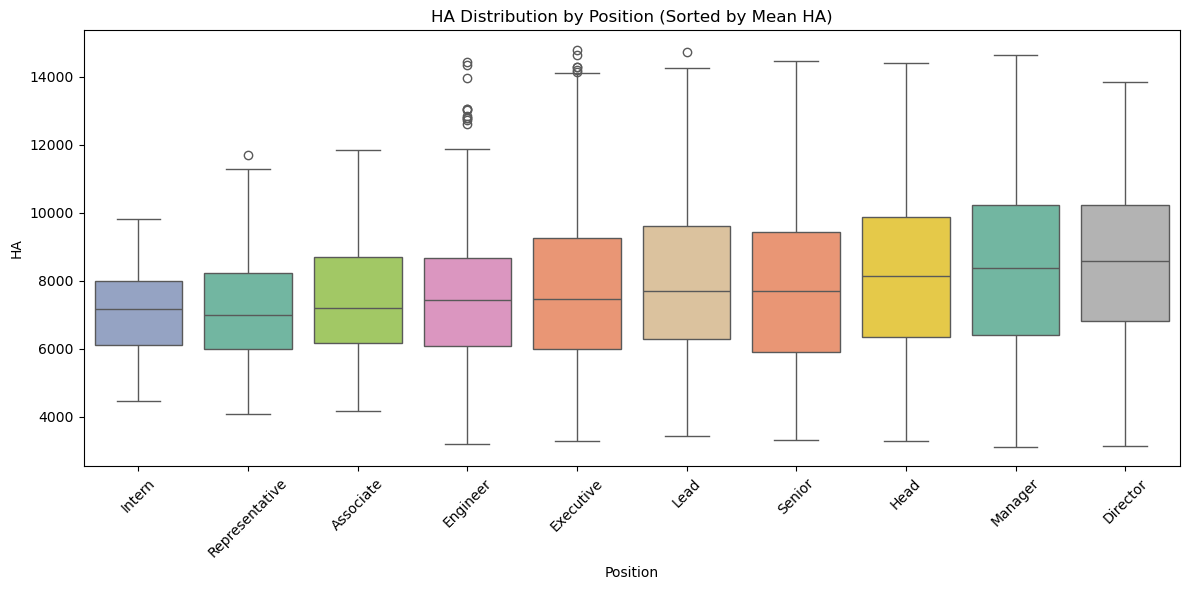

In [34]:
# Step 4f: Let's find a relation between HA and Position

average_HA = employee_data.groupby('Position')['HA'].mean().sort_values().index

plt.figure(figsize=(12, 6))
sns.boxplot(x='Position', y='HA', data=employee_data, order=average_HA, hue='Position', palette='Set2', dodge=False, legend=False)
plt.title('HA Distribution by Position (Sorted by Mean HA)')
plt.xlabel('Position')
plt.ylabel('HA')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

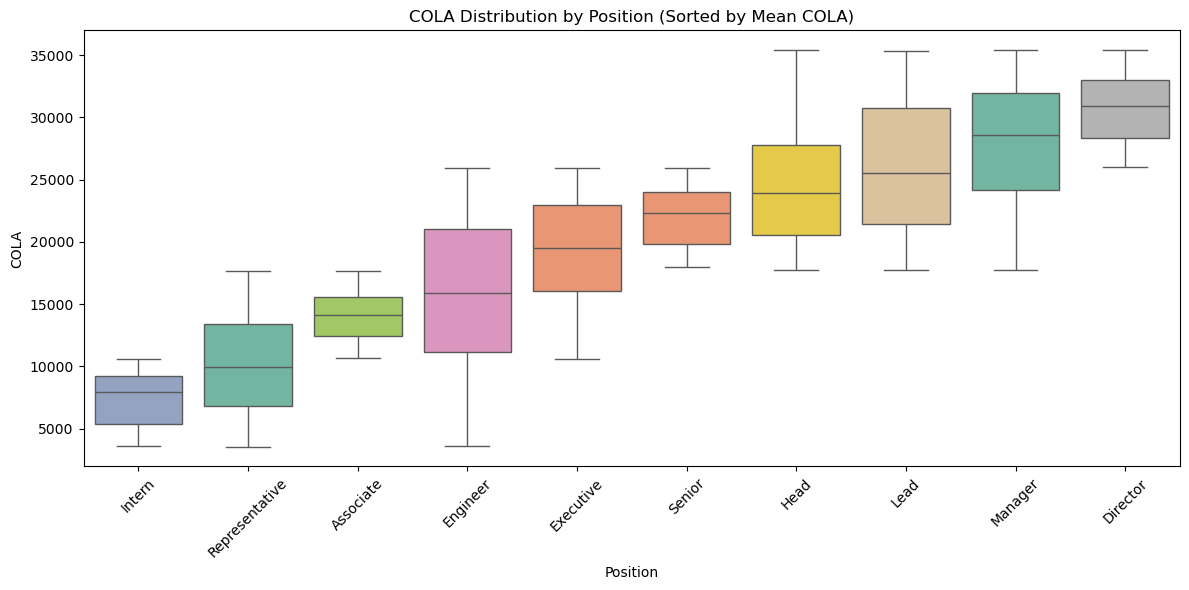

In [36]:
# Step 4g: Let's find a relation between COLA and Position

average_COLA = employee_data.groupby('Position')['COLA'].mean().sort_values().index

plt.figure(figsize=(12, 6))
sns.boxplot(x='Position', y='COLA', data=employee_data, order=average_COLA, hue='Position', palette='Set2', dodge=False, legend=False)
plt.title('COLA Distribution by Position (Sorted by Mean COLA)')
plt.xlabel('Position')
plt.ylabel('COLA')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

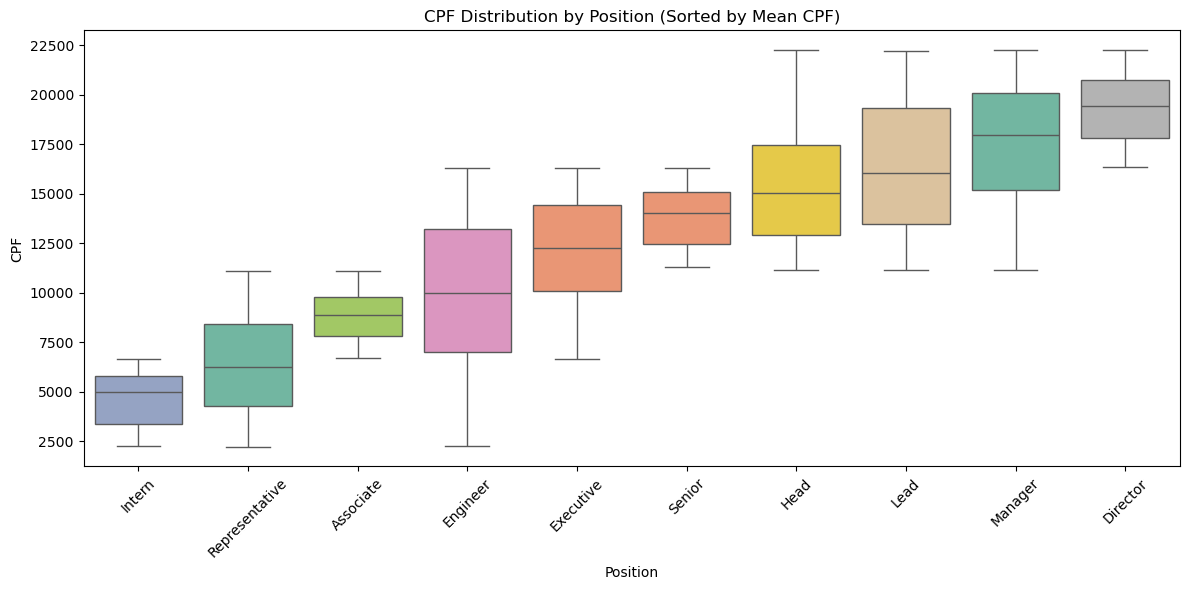

In [40]:
# Step 4h: Let's find a relation between CPF and Position

average_CPF = employee_data.groupby('Position')['CPF'].mean().sort_values().index

plt.figure(figsize=(12, 6))
sns.boxplot(x='Position', y='CPF', data=employee_data, order=average_CPF, hue='Position', palette='Set2', dodge=False, legend=False)
plt.title('CPF Distribution by Position (Sorted by Mean CPF)')
plt.xlabel('Position')
plt.ylabel('CPF')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

We can conclude that the order is { Intern, Representative, Associate, Engineer, Executive, Senior, Head, Lead, Manager, Director }

Gender
Other     1546
Male      1528
Female    1526
Name: count, dtype: int64

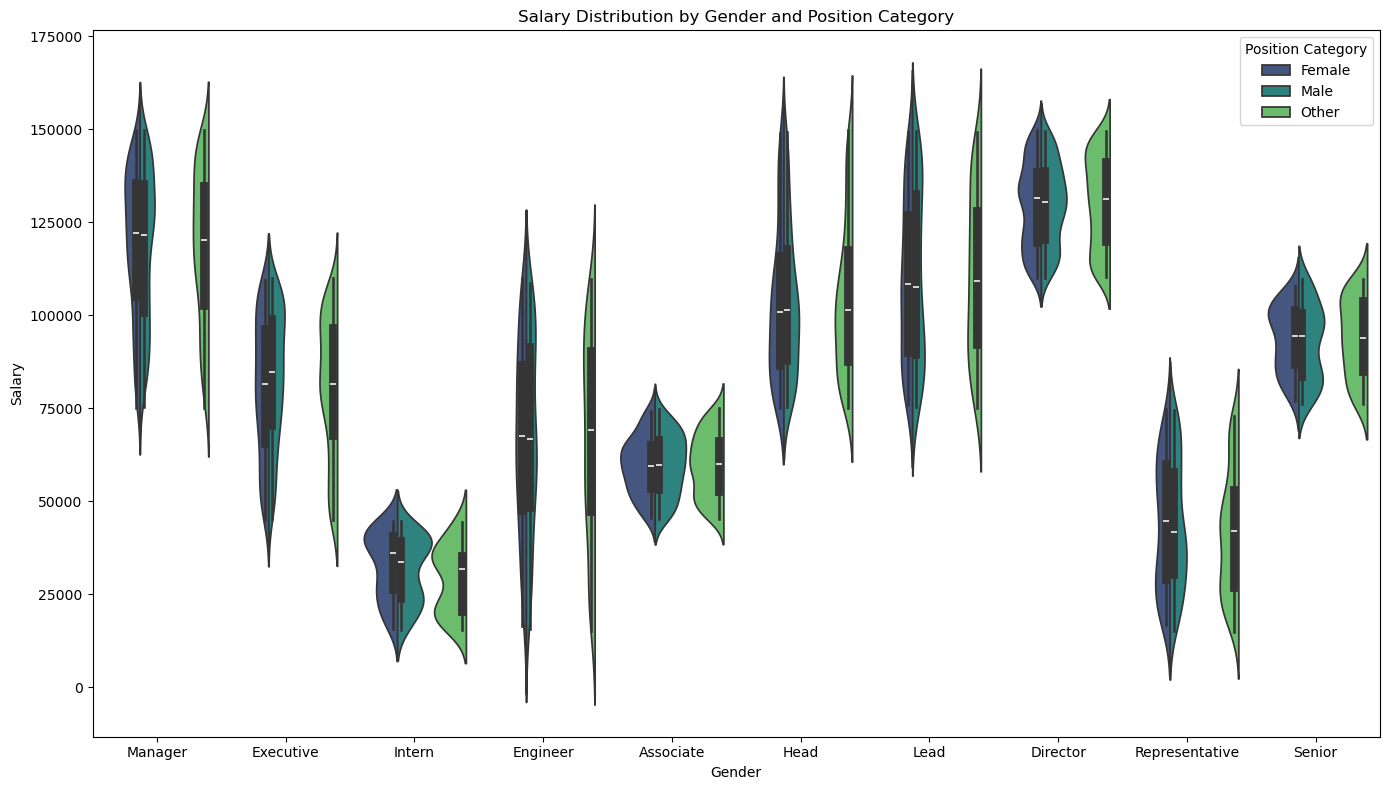

In [44]:
# Step 4i: Violin plot for Salary by Gender and Position Category

display(employee_data['Gender'].value_counts())
plt.figure(figsize=(14, 8))
sns.violinplot(x='Position', y='Salary', hue='Gender', data=employee_data, palette='viridis', split=True)
plt.title('Salary Distribution by Gender and Position Category')
plt.xlabel('Gender')
plt.ylabel('Salary')
plt.legend(title='Position Category')
plt.tight_layout()
plt.show()

#### *Correlation Between CPF and COLA

In [68]:
# Supplementary : From the slides * 

employee_data_clean = employee_data.dropna(subset=['COLA', 'CPF'])

pearson_corr, pearson_p_value = stats.pearsonr(employee_data_clean['COLA'], employee_data_clean['CPF'])

print(f"Pearson Correlation Coefficient: {pearson_corr}")
print(f"P-value: {pearson_p_value}")

alpha = 0.05
if pearson_p_value < alpha:
    print("Reject the null hypothesis: There is a significant correlation between COLA and CPF.")
else:
    print("Fail to reject the null hypothesis: There is no significant correlation between COLA and CPF.")

positions = employee_data['Position'].unique()

position_correlations = []

for position in positions:
    position_data = employee_data_clean[employee_data_clean['Position'] == position]
    
    if len(position_data) < 2:
        print(f"Not enough data for position {position}, skipping.")
        continue
    
    corr, p_value = stats.pearsonr(position_data['COLA'], position_data['CPF'])
    
    position_correlations.append({
        'Position': position,
        'Correlation': corr,
        'P-value': p_value
    })

position_corr_df = pd.DataFrame(position_correlations)

print(position_corr_df)

Pearson Correlation Coefficient: 1.0
P-value: 0.0
Reject the null hypothesis: There is a significant correlation between COLA and CPF.
         Position  Correlation  P-value
0         Manager          1.0      0.0
1       Executive          1.0      0.0
2          Intern          1.0      0.0
3        Engineer          1.0      0.0
4       Associate          1.0      0.0
5            Head          1.0      0.0
6            Lead          1.0      0.0
7        Director          1.0      0.0
8  Representative          1.0      0.0
9          Senior          1.0      0.0


## INFERENTIAL STATISTICS

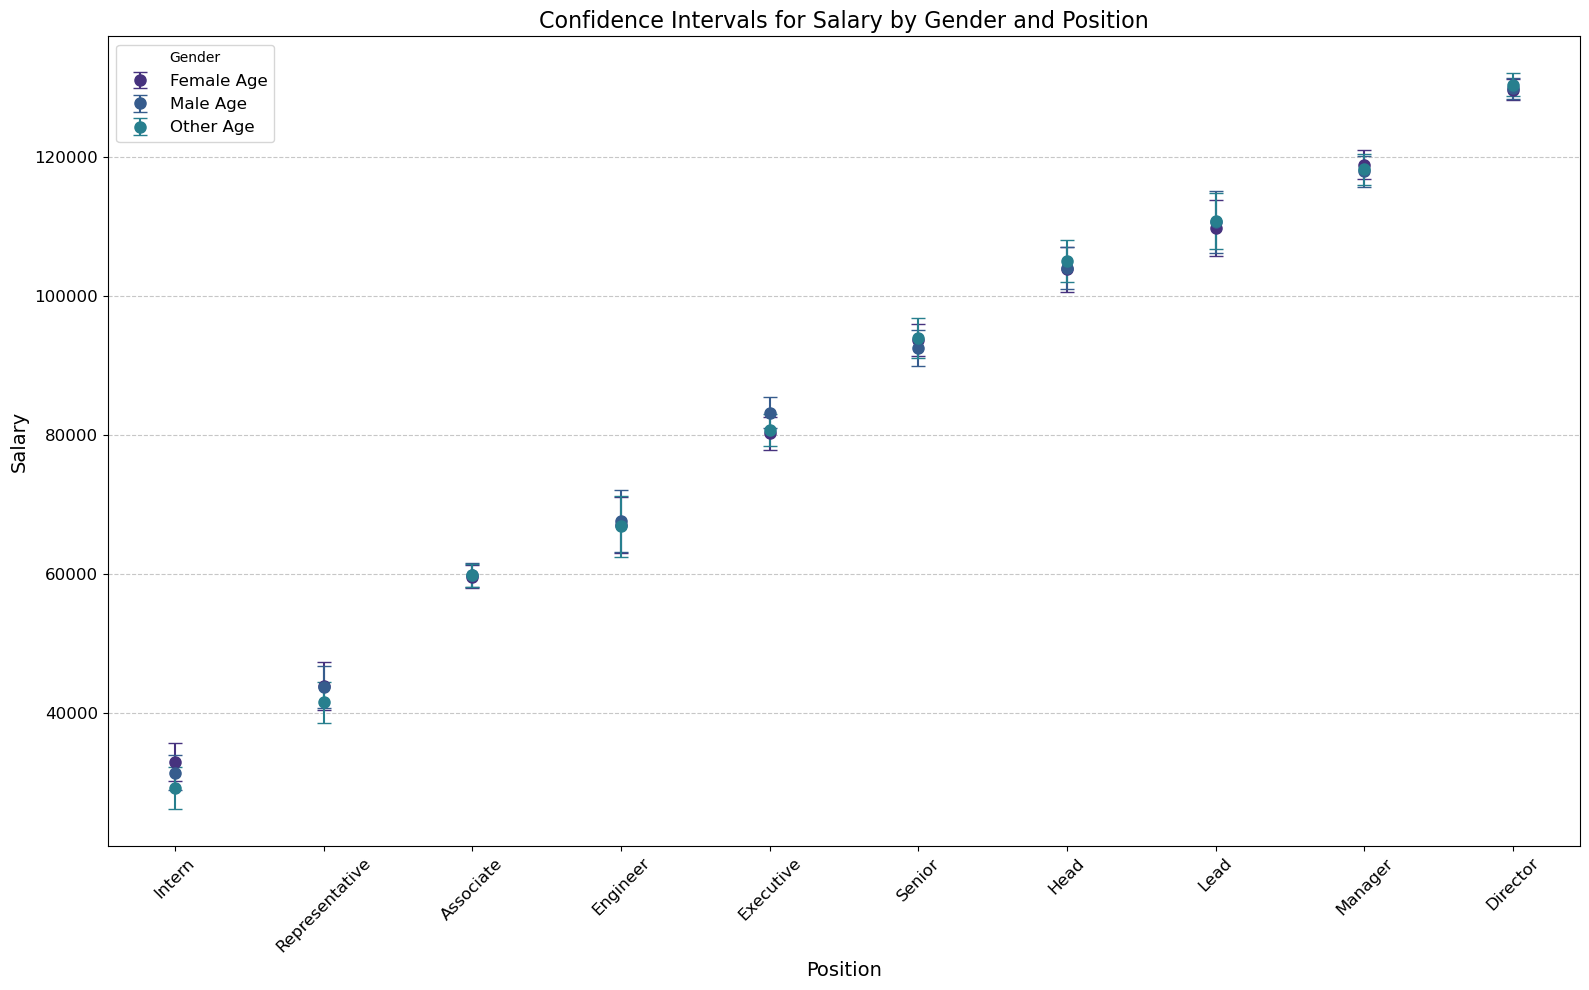

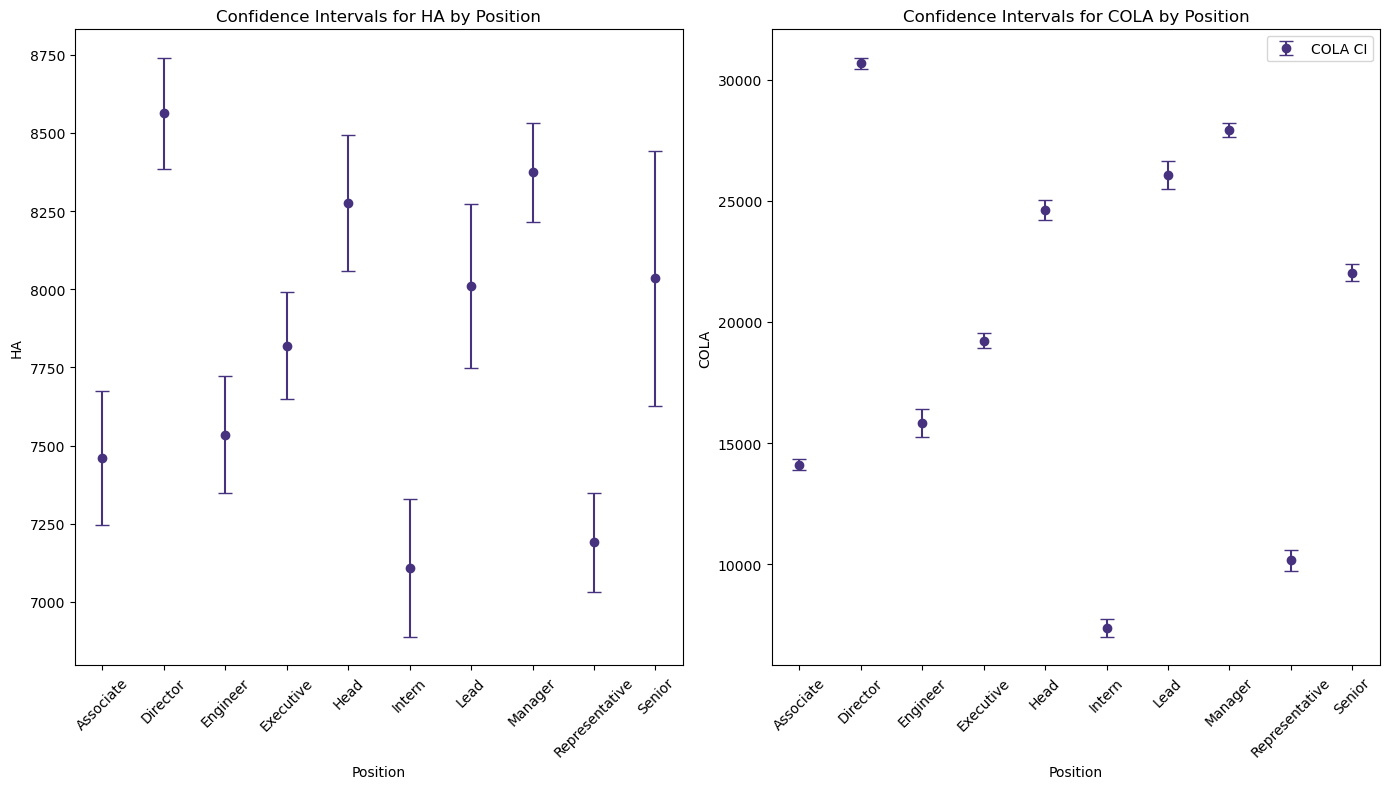

In [48]:
#
# Function to plot confidence intervals for Age by Gender and Position
def plot_confidence_intervals_salary_gender_position(data, confidence=0.95):
    plt.figure(figsize=(16, 10))
    sns.set_palette("viridis")
    
    # Specified order for positions
    position_order = ['Intern', 'Representative', 'Associate', 'Engineer', 'Executive', 
                      'Senior', 'Head', 'Lead', 'Manager', 'Director']
    
    for gender in data['Gender'].unique():
        subset = data[data['Gender'] == gender]
        mean_ages = subset.groupby('Position')['Salary'].mean().reindex(position_order)
        std_ages = subset.groupby('Position')['Salary'].std().reindex(position_order)
        n_ages = subset.groupby('Position')['Salary'].count().reindex(position_order)
        
        # Compute the margin of error -- using 
        margin_of_error = stats.t.ppf((1 + confidence) / 2., n_ages - 1) * (std_ages / np.sqrt(n_ages))
        
        # Plot mean age with error bars for confidence intervals
        plt.errorbar(mean_ages.index, mean_ages, yerr=margin_of_error, fmt='o', label=f'{gender} Age', capsize=5, markersize=8)
    
    plt.title('Confidence Intervals for Salary by Gender and Position', fontsize=16)
    plt.xlabel('Position', fontsize=14)
    plt.ylabel('Salary', fontsize=14)
    plt.legend(title='Gender', fontsize=12)
    plt.xticks(rotation=45, fontsize=12)
    plt.yticks(fontsize=12)
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

# Function to plot confidence intervals for HA and COLA by Position
def plot_confidence_intervals_benefits(data, confidence=0.95):
    plt.figure(figsize=(14, 8))
    benefits = ['HA', 'COLA']
    
    for i, benefit in enumerate(benefits):
        plt.subplot(1, 2, i + 1)
        mean_benefits = data.groupby('Position')[benefit].mean()
        std_benefits = data.groupby('Position')[benefit].std()
        n_benefits = data.groupby('Position')[benefit].count()
        
        # Compute the margin of error
        margin_of_error = stats.t.ppf((1 + confidence) / 2., n_benefits - 1) * (std_benefits / np.sqrt(n_benefits))
        
        # Plot mean benefit with error bars for confidence intervals
        plt.errorbar(mean_benefits.index, mean_benefits, yerr=margin_of_error, fmt='o', label=f'{benefit} CI', capsize=5)
        plt.title(f'Confidence Intervals for {benefit} by Position')
        plt.xlabel('Position')
        plt.ylabel(benefit)
        plt.xticks(rotation=45)
        plt.tight_layout()
    
    plt.legend()
    plt.show()

# Apply the functions to plot the confidence intervals
plot_confidence_intervals_salary_gender_position(employee_data)
plot_confidence_intervals_benefits(employee_data)


## HYPOTHESIS TESTING

H_0: There is no significant difference in pay between male and female employees within the same positions.

H_1: There is a significant difference in pay between male and female employees within the same positions.

In [126]:
# Get all unique positions
positions = employee_data['Position'].unique()  

# List to store t-test results
results = []

# Loop through each position
for position in positions:
    # Get male and female salaries for the current position, removing missing values
    male_salaries = employee_data[(employee_data['Gender'] == 'Male') & (employee_data['Position'] == position)]['Salary'].dropna()
    female_salaries = employee_data[(employee_data['Gender'] == 'Female') & (employee_data['Position'] == position)]['Salary'].dropna()
    
    # Skip the position if there are not enough data points for males or females
    if len(male_salaries) < 2 or len(female_salaries) < 2:
        print(f"Not enough data for position {position}, skipping t-test.")
        continue
    
    # Perform the independent t-test (assuming unequal variances)
    t_stat, p_value = stats.ttest_ind(male_salaries, female_salaries, equal_var=False)

    # Store the results in a list
    results.append({
        'Position': position,
        'T-statistic': t_stat,
        'P-value': p_value,
        'Significant Difference': p_value < 0.05  # Significant if p-value is less than 0.05
    })

# Convert results to a DataFrame for easier viewing
results_df = pd.DataFrame(results)

# Output the t-test results
print(results_df)

         Position  T-statistic   P-value  Significant Difference
0         Manager    -0.603089  0.546654                   False
1       Executive     1.822753  0.068948                   False
2          Intern    -0.839359  0.403532                   False
3        Engineer     0.170895  0.864432                   False
4       Associate     0.157677  0.874894                   False
5            Head     0.108167  0.913929                   False
6            Lead     0.277591  0.781593                   False
7        Director     0.159398  0.873432                   False
8  Representative    -0.047357  0.962275                   False
9          Senior    -0.632148  0.528520                   False


H_0: There are no significant differences in Housing Allowance (HA) among employees in different departments.

H_1: There are significant differences in Housing Allowance (HA) among employees in different departments.

In [52]:
# Group the data by position
grouped_by_position = employee_data.groupby('Position')

# Extract positions and corresponding Housing Allowance (HA)
positions = employee_data['Position']
ha = employee_data['HA'].dropna()  # Housing Allowance

# Perform one-way ANOVA for Housing Allowance across different positions
f_stat_ha, p_value_ha = stats.f_oneway(*[group['HA'].dropna() for name, group in grouped_by_position])

# Output ANOVA results for Housing Allowance
print(f"ANOVA F-statistic for HA by Position: {f_stat_ha}, P-value: {p_value_ha}")

# Set significance level
alpha = 0.05

# Check significance for HA differences across positions
if p_value_ha < alpha:
    print("Reject the null hypothesis: There are significant differences in HA across different positions.")
    
    # Post-hoc test - Perform Tukey's test for multiple comparisons
    tukey_ha = pairwise_tukeyhsd(endog=ha, groups=positions, alpha=alpha)
    print(tukey_ha)
else:
    print("Fail to reject the null hypothesis: No significant differences in HA across different positions.")

ANOVA F-statistic for HA by Position: 19.391961180416473, P-value: 3.1199812419741345e-32
Reject the null hypothesis: There are significant differences in HA across different positions.
            Multiple Comparison of Means - Tukey HSD, FWER=0.05            
    group1         group2      meandiff  p-adj    lower      upper   reject
---------------------------------------------------------------------------
     Associate       Director  1101.9452    0.0   585.0006 1618.8898   True
     Associate       Engineer    74.7536    1.0  -479.9417  629.4489  False
     Associate      Executive    358.416 0.4273  -147.4113  864.2433  False
     Associate           Head   816.2356 0.0001   280.2014 1352.2698   True
     Associate         Intern  -351.6081   0.91  -1117.396  414.1797  False
     Associate           Lead   550.4317 0.0862     -35.05 1135.9134  False
     Associate        Manager   913.5166    0.0   425.2076 1401.8255   True
     Associate Representative  -270.4349 0.9016  -850.

H_0: There are no significant differences in Cost of Living Adjustments (COLA) among employees in different departments.

H_1: There are significant differences in Cost of Living Adjustments (COLA) among employees in different departments.

In [54]:
# Perform one-way ANOVA for Cost of Living Adjustments (COLA)
f_stat_cola, p_value_cola = stats.f_oneway(*[group['COLA'].dropna() for name, group in grouped_by_position])

# Output ANOVA results for COLA
print(f"ANOVA F-statistic for COLA by Position: {f_stat_cola}, P-value: {p_value_cola}")

# Check significance for COLA differences across positions
if p_value_cola < alpha:
    print("Reject the null hypothesis: There are significant differences in COLA across different positions.")
    
    # Post-hoc test - Perform Tukey's test for multiple comparisons
    tukey_cola = pairwise_tukeyhsd(endog=employee_data['COLA'].dropna(), groups=employee_data['Position'], alpha=alpha)
    print(tukey_cola)
else:
    print("Fail to reject the null hypothesis: No significant differences in COLA across different positions.")

ANOVA F-statistic for COLA by Position: 1224.2653542919566, P-value: 0.0
Reject the null hypothesis: There are significant differences in COLA across different positions.
              Multiple Comparison of Means - Tukey HSD, FWER=0.05              
    group1         group2       meandiff  p-adj     lower       upper    reject
-------------------------------------------------------------------------------
     Associate       Director  16578.4808    0.0   15595.462  17561.4996   True
     Associate       Engineer    1744.851    0.0    690.0456   2799.6564   True
     Associate      Executive   5117.0576    0.0   4155.1792   6078.9359   True
     Associate           Head  10522.0187    0.0   9502.6991  11541.3382   True
     Associate         Intern  -6723.1405    0.0  -8179.3583  -5266.9227   True
     Associate           Lead  11965.2618    0.0  10851.9131  13078.6104   True
     Associate        Manager  13830.6111    0.0  12902.0456  14759.1766   True
     Associate Representative